In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/beyondblue_data_flattened_transformers_twitter_english_enriched.csv")

# Ensure datetime is correct
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.sort_values(['parent_post_id', 'date']).reset_index(drop=True)
df.head()

,parent_post_id,user_id,role,text,date,category,sentiment_dist,valence_s,sentiment_top,sentiment_conf,emotion_dist,valence_e,arousal_e,emotion_top,emotion_conf
0,1,Toby,original,"Struggling at the moment. Hello everyone, this...",2025-07-16,Anxiety,"{'NEGATIVE': 0.6358407139778137, 'NEUTRAL': 0....",-0.573183,NEGATIVE,0.635841,"{'anger': 0.0030326072592288256, 'disgust': 0....",0.079505,0.828274,fear,0.969302
1,1,Morph,commenter,"Hi Toby, welcome and congratulations on your f...",2025-07-17,Anxiety,"{'NEGATIVE': 0.002651855116710067, 'NEUTRAL': ...",0.971309,POSITIVE,0.973961,"{'anger': 0.0023175962269306183, 'disgust': 0....",0.877638,0.714559,joy,0.780846
2,1,AudaciousPoodle,commenter,"Hi Toby, Reading your post sounds just like wh...",2025-07-17,Anxiety,"{'NEGATIVE': 0.7963150143623352, 'NEUTRAL': 0....",-0.754034,NEGATIVE,0.796315,"{'anger': 0.010348315350711346, 'disgust': 0.0...",0.071904,0.324703,sadness,0.913931
3,1,_Gigi_,commenter,"Hello Toby,I'm glad you've decided to reach ou...",2025-07-18,Anxiety,"{'NEGATIVE': 0.01175833772867918, 'NEUTRAL': 0...",0.903619,POSITIVE,0.915377,"{'anger': 0.0013056608149781823, 'disgust': 0....",0.867446,0.751704,joy,0.845598
4,1,Toby,op_reply,My anxiety is affecting my whole life. When I ...,2025-07-18,Anxiety,"{'NEGATIVE': 0.6501989364624023, 'NEUTRAL': 0....",-0.580363,NEGATIVE,0.650199,"{'anger': 0.010438608936965466, 'disgust': 0.0...",0.253667,0.546303,sadness,0.477066


In [104]:
# Identify OP for each parent_post_id
op_map = df[df['role']=="original"].groupby('parent_post_id')['user_id'].first().to_dict()

df['is_op'] = df.apply(lambda r: r['user_id'] == op_map[r['parent_post_id']], axis=1)

In [105]:
op_sequences = []

for pid, g in df.groupby('parent_post_id'):
    g = g.sort_values('date').reset_index(drop=True)

    # find OP initial post
    op_first = g[g['role']=='original'].iloc[0]
    
    # find OP replies AFTER receiving comments
    op_replies = g[(g['role']=='op_reply')]
    
    for _, reply in op_replies.iterrows():
        comments_before = g[(g['role']=='commenter') & (g['date'] < reply['date'])]
        if len(comments_before) > 0:
            op_sequences.append({
                'parent_post_id': pid,
                'op_initial_valence': op_first['valence_e'],
                'op_initial_arousal': op_first['arousal_e'],
                'op_reply_valence': reply['valence_e'],
                'op_reply_arousal': reply['arousal_e'],
                'n_comments_before_reply': len(comments_before)
            })

op_seq_df = pd.DataFrame(op_sequences)
op_seq_df.head()

,parent_post_id,op_initial_valence,op_initial_arousal,op_reply_valence,op_reply_arousal,n_comments_before_reply
0,1,0.079505,0.828274,0.253667,0.546303,2
1,4,0.155748,0.763703,0.653773,0.440717,1
2,17,0.272267,0.689516,0.870684,0.743138,4
3,17,0.272267,0.689516,0.066370,0.302870,4
4,17,0.272267,0.689516,0.118633,0.327014,4


In [106]:
op_seq_df['delta_valence'] = op_seq_df['op_reply_valence'] - op_seq_df['op_initial_valence']
op_seq_df['delta_arousal'] = op_seq_df['op_reply_arousal'] - op_seq_df['op_initial_arousal']

In [107]:
print("Mean change in valence:", op_seq_df['delta_valence'].mean())
print("Mean change in arousal:", op_seq_df['delta_arousal'].mean())

Mean change in valence: 0.235735322871854
Mean change in arousal: 0.016864657486422092


Interpretation:
- delta_valence > 0 → OP becomes more positive
- delta_valence < 0 → OP becomes more distressed / depressed
- delta_arousal > 0 → OP becomes more activated / anxious / energized
- delta_arousal < 0 → OP becomes more withdrawn / numbed


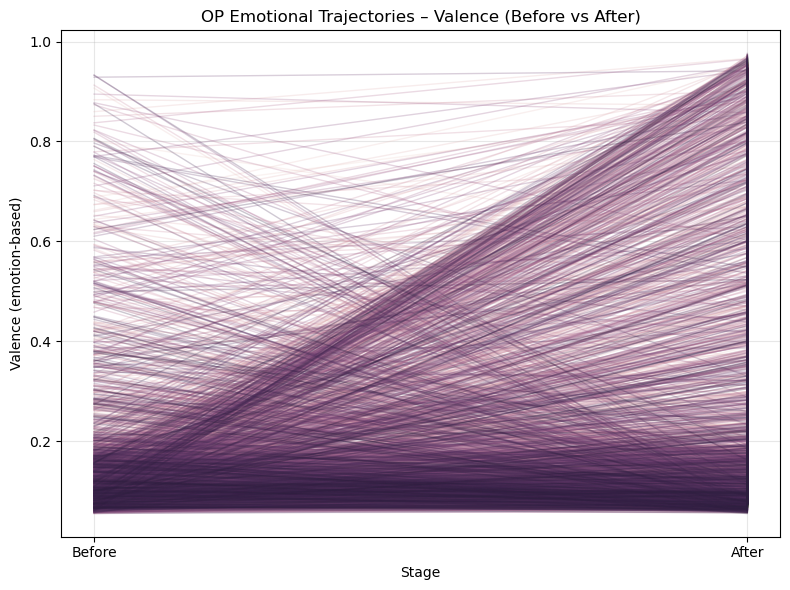

In [108]:
# ---------- Valence trajectories (Before vs After) ----------
valence_plot = pd.DataFrame({
    'parent_post_id': op_seq_df['parent_post_id'],
    'Before': op_seq_df['op_initial_valence'],
    'After':  op_seq_df['op_reply_valence']
})

valence_long = valence_plot.melt(
    id_vars='parent_post_id',
    value_vars=['Before', 'After'],
    var_name='Stage',
    value_name='Valence'
)

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=valence_long,
    x='Stage',
    y='Valence',
    hue='parent_post_id',
    estimator=None,
    alpha=0.25,
    linewidth=1
)
plt.title('OP Emotional Trajectories – Valence (Before vs After)')
plt.xlabel('Stage')
plt.ylabel('Valence (emotion-based)')
plt.legend([], [], frameon=False)  # hide legend (too many lines)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/jm/36rrr53s1w388ms7208drrcm0000gn/T/ipykernel_13379/2943173630.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


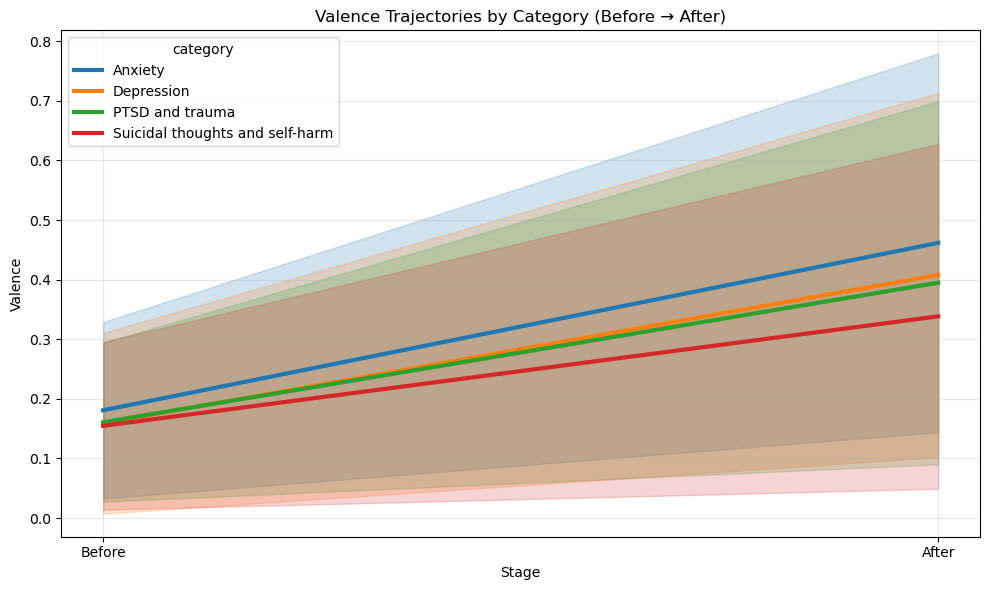

In [109]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=valence_long_cat,
    x='Stage',
    y='Valence',
    hue='category',
    estimator='mean',
    ci='sd',
    linewidth=3
)
plt.title("Valence Trajectories by Category (Before → After)")
plt.xlabel("Stage")
plt.ylabel("Valence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

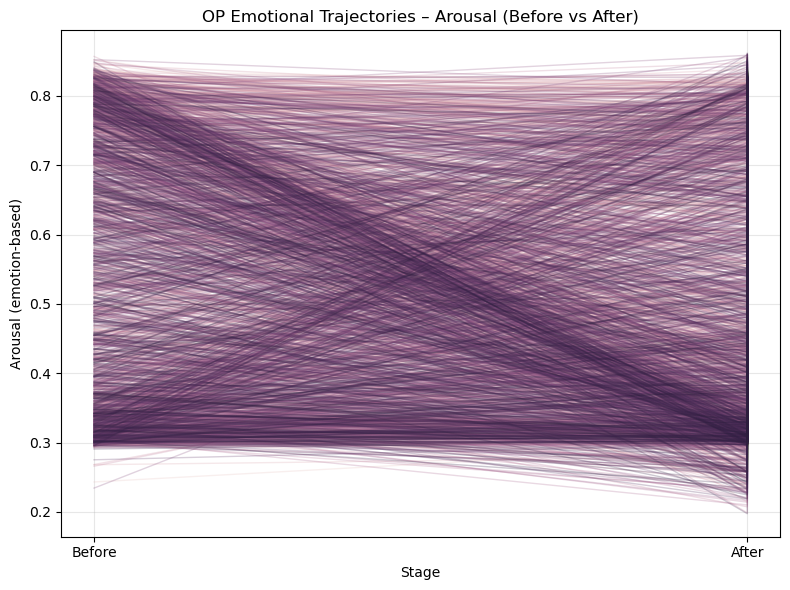

In [110]:
# ---------- Arousal trajectories (Before vs After) ----------
arousal_plot = pd.DataFrame({
    'parent_post_id': op_seq_df['parent_post_id'],
    'Before': op_seq_df['op_initial_arousal'],
    'After':  op_seq_df['op_reply_arousal']
})

arousal_long = arousal_plot.melt(
    id_vars='parent_post_id',
    value_vars=['Before', 'After'],
    var_name='Stage',
    value_name='Arousal'
)

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=arousal_long,
    x='Stage',
    y='Arousal',
    hue='parent_post_id',
    estimator=None,
    alpha=0.25,
    linewidth=1
)
plt.title('OP Emotional Trajectories – Arousal (Before vs After)')
plt.xlabel('Stage')
plt.ylabel('Arousal (emotion-based)')
plt.legend([], [], frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/jm/36rrr53s1w388ms7208drrcm0000gn/T/ipykernel_13379/409403842.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


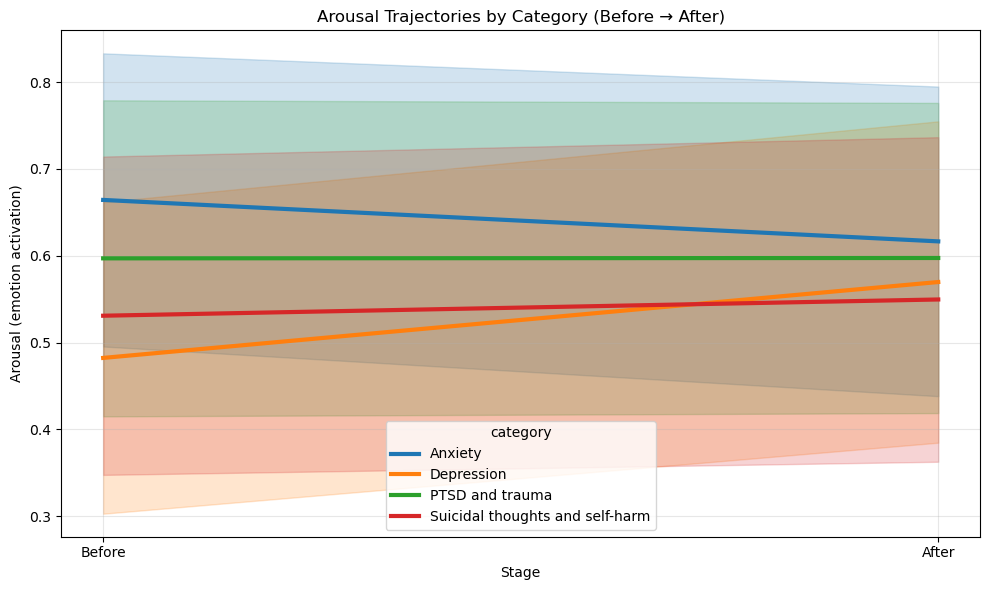

In [111]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=arousal_long_cat,
    x='Stage',
    y='Arousal',
    hue='category',
    estimator='mean',
    ci='sd',
    linewidth=3
)
plt.title("Arousal Trajectories by Category (Before → After)")
plt.xlabel("Stage")
plt.ylabel("Arousal (emotion activation)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

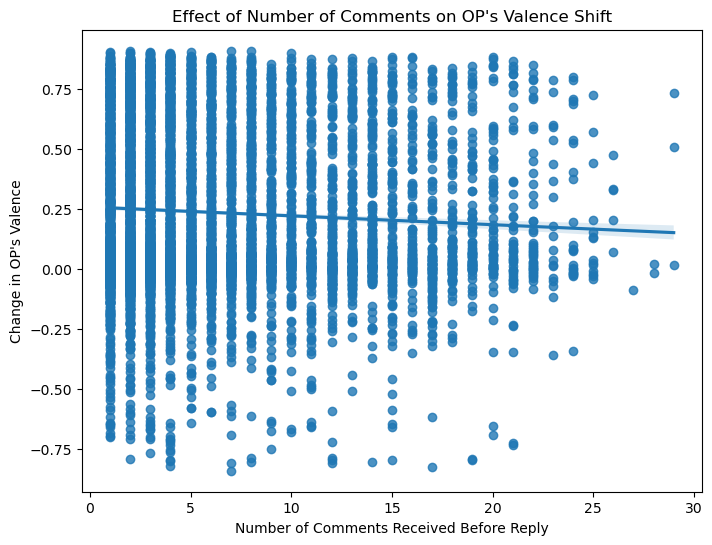

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(data=op_seq_df, x="n_comments_before_reply", y="delta_valence")
plt.title("Effect of Number of Comments on OP's Valence Shift")
plt.xlabel("Number of Comments Received Before Reply")
plt.ylabel("Change in OP's Valence")
plt.show()

In [113]:
def avg_comment_emotion(g):
    comments = g[g['role']=='commenter']
    if len(comments)==0:
        return None
    return comments['emotion_top'].value_counts(normalize=True).to_dict()

comment_emotion_stats = []

for pid, g in df.groupby('parent_post_id'):
    g = g.sort_values('date')
    comemo = avg_comment_emotion(g)
    if comemo:
        comment_emotion_stats.append({
            'parent_post_id': pid,
            'pct_sadness': comemo.get('sadness',0),
            'pct_fear': comemo.get('fear',0),
            'pct_joy': comemo.get('joy',0),
            'pct_neutral': comemo.get('neutral',0)
        })

emo_df = pd.DataFrame(comment_emotion_stats)

In [114]:
merged = op_seq_df.merge(emo_df, on='parent_post_id', how='left')

In [115]:
merged[['delta_valence','pct_joy','pct_neutral','pct_sadness','pct_fear']].corr()

,delta_valence,pct_joy,pct_neutral,pct_sadness,pct_fear
delta_valence,1.000000,0.116643,-0.027402,-0.066122,-0.006385
pct_joy,0.116643,1.000000,-0.297385,-0.309397,-0.246054
pct_neutral,-0.027402,-0.297385,1.000000,-0.359078,-0.118340
pct_sadness,-0.066122,-0.309397,-0.359078,1.000000,-0.342748
pct_fear,-0.006385,-0.246054,-0.118340,-0.342748,1.000000


In [116]:
# ---- Emotion labels used in your dist (7-way) ----
emo_labels = ["anger","disgust","fear","joy","neutral","sadness","surprise"]

# ---- compute full 7-emotion proportion for each parent_post_id ----

emotion_stats = []

for pid, g in df.groupby("parent_post_id"):
    # only commenter messages
    com = g[g['role'] == "commenter"]

    if len(com) == 0:
        continue

    # compute frequency of each emotion_top
    proportions = com['emotion_top'].value_counts(normalize=True).to_dict()

    row = {"parent_post_id": pid}
    for emo in emo_labels:
        row[f"pct_{emo}"] = proportions.get(emo, 0.0)

    emotion_stats.append(row)

emo_7_df = pd.DataFrame(emotion_stats)
emo_7_df.head()

,parent_post_id,pct_anger,pct_disgust,pct_fear,pct_joy,pct_neutral,pct_sadness,pct_surprise
0,1,0.0,0.0,0.0,0.666667,0.0,0.333333,0.0
1,2,0.0,0.0,0.5,0.000000,0.0,0.000000,0.5
2,3,0.0,0.0,1.0,0.000000,0.0,0.000000,0.0
3,4,0.0,0.0,0.0,0.000000,0.0,1.000000,0.0
4,5,0.0,0.0,0.0,0.000000,1.0,0.000000,0.0


In [117]:
merged_7 = op_seq_df.merge(emo_7_df, on="parent_post_id", how="left")
merged_7.head()

,parent_post_id,op_initial_valence,op_initial_arousal,op_reply_valence,op_reply_arousal,n_comments_before_reply,delta_valence,delta_arousal,pct_anger,pct_disgust,pct_fear,pct_joy,pct_neutral,pct_sadness,pct_surprise
0,1,0.079505,0.828274,0.253667,0.546303,2,0.174162,-0.281971,0.0,0.0,0.000000,0.666667,0.000000,0.333333,0.000000
1,4,0.155748,0.763703,0.653773,0.440717,1,0.498025,-0.322987,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000
2,17,0.272267,0.689516,0.870684,0.743138,4,0.598417,0.053622,0.0,0.0,0.090909,0.681818,0.090909,0.090909,0.045455
3,17,0.272267,0.689516,0.066370,0.302870,4,-0.205897,-0.386646,0.0,0.0,0.090909,0.681818,0.090909,0.090909,0.045455
4,17,0.272267,0.689516,0.118633,0.327014,4,-0.153634,-0.362502,0.0,0.0,0.090909,0.681818,0.090909,0.090909,0.045455


In [118]:
corr_cols = ["delta_valence"] + [f"pct_{emo}" for emo in emo_labels]

corr_matrix_7 = merged_7[corr_cols].corr()

corr_matrix_7

,delta_valence,pct_anger,pct_disgust,pct_fear,pct_joy,pct_neutral,pct_sadness,pct_surprise
delta_valence,1.000000,-0.022636,0.013956,-0.006385,0.116643,-0.027402,-0.066122,-0.011054
pct_anger,-0.022636,1.000000,0.014931,-0.122531,-0.193527,-0.098690,-0.135374,-0.006404
pct_disgust,0.013956,0.014931,1.000000,-0.061549,-0.084068,-0.041557,-0.054219,-0.019231
pct_fear,-0.006385,-0.122531,-0.061549,1.000000,-0.246054,-0.118340,-0.342748,-0.091473
pct_joy,0.116643,-0.193527,-0.084068,-0.246054,1.000000,-0.297385,-0.309397,-0.118480
pct_neutral,-0.027402,-0.098690,-0.041557,-0.118340,-0.297385,1.000000,-0.359078,-0.141604
pct_sadness,-0.066122,-0.135374,-0.054219,-0.342748,-0.309397,-0.359078,1.000000,-0.141158
pct_surprise,-0.011054,-0.006404,-0.019231,-0.091473,-0.118480,-0.141604,-0.141158,1.000000


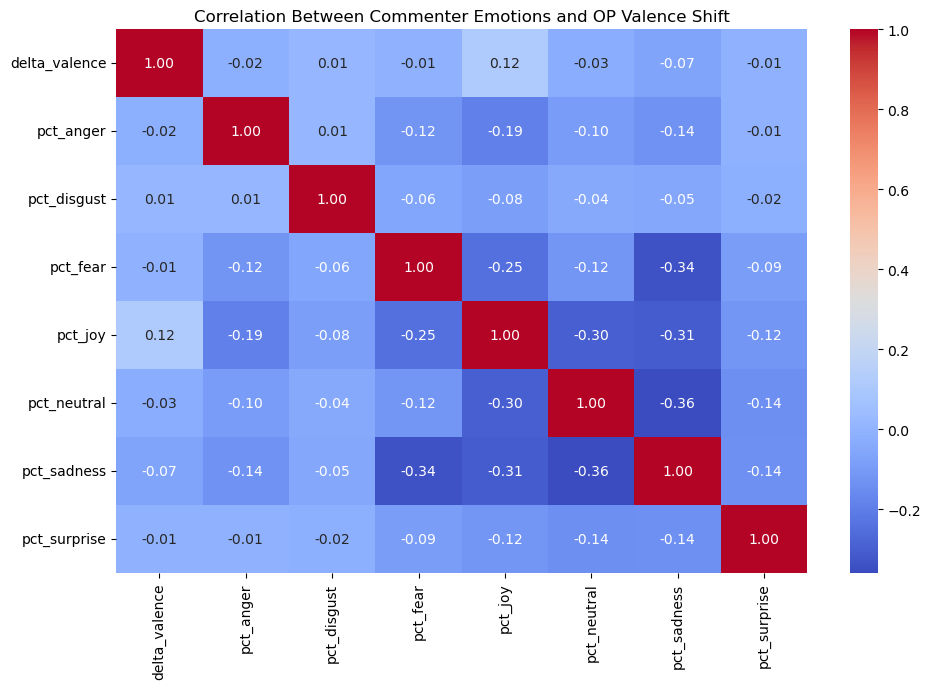

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix_7, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Commenter Emotions and OP Valence Shift")
plt.tight_layout()
plt.show()